<a href="https://colab.research.google.com/github/dystaSatria/Deep-Learning/blob/main/Internship%20Projects/f2/f2skoru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🎮 DenseNet F2 Skoru Demonstrasyonu
📱 Kullanılan device: cpu

📊 İmbalanced dataset oluşturuluyor...
📈 Sınıf dağılımı:
  Normal: 400 sample
  Anomaly-1: 250 sample
  Anomaly-2: 200 sample
  Rare-Disease: 100 sample
  Critical-Case: 50 sample
📚 Dataset split: Train=600, Val=200, Test=200

🏗️ DenseNet modeli oluşturuluyor...
📊 Toplam parametre sayısı: 619,525

🚀 Model eğitimi ve F2 değerlendirmesi başlıyor...
🚀 DenseNet F2-Optimized Training Başlıyor...

📅 Epoch 1/8
----------------------------------------
  Batch 0/19 - Loss: 1.5797
  🎯 Yeni en iyi F2 skoru! Model kaydedildi.
  📊 Train Loss: 0.1811
  📊 Val Loss: 0.0121
  📊 Val Accuracy: 1.0000
  🎯 Val F2 Score: 1.0000
  🏆 Best F2: 1.0000

📅 Epoch 2/8
----------------------------------------
  Batch 0/19 - Loss: 0.0002
  📊 Train Loss: 0.0000
  📊 Val Loss: 0.0000
  📊 Val Accuracy: 1.0000
  🎯 Val F2 Score: 1.0000
  🏆 Best F2: 1.0000

📅 Epoch 3/8
----------------------------------------
  Batch 0/19 - Loss: 0.0000
  📊 Train Loss: 0.0000
  📊 V

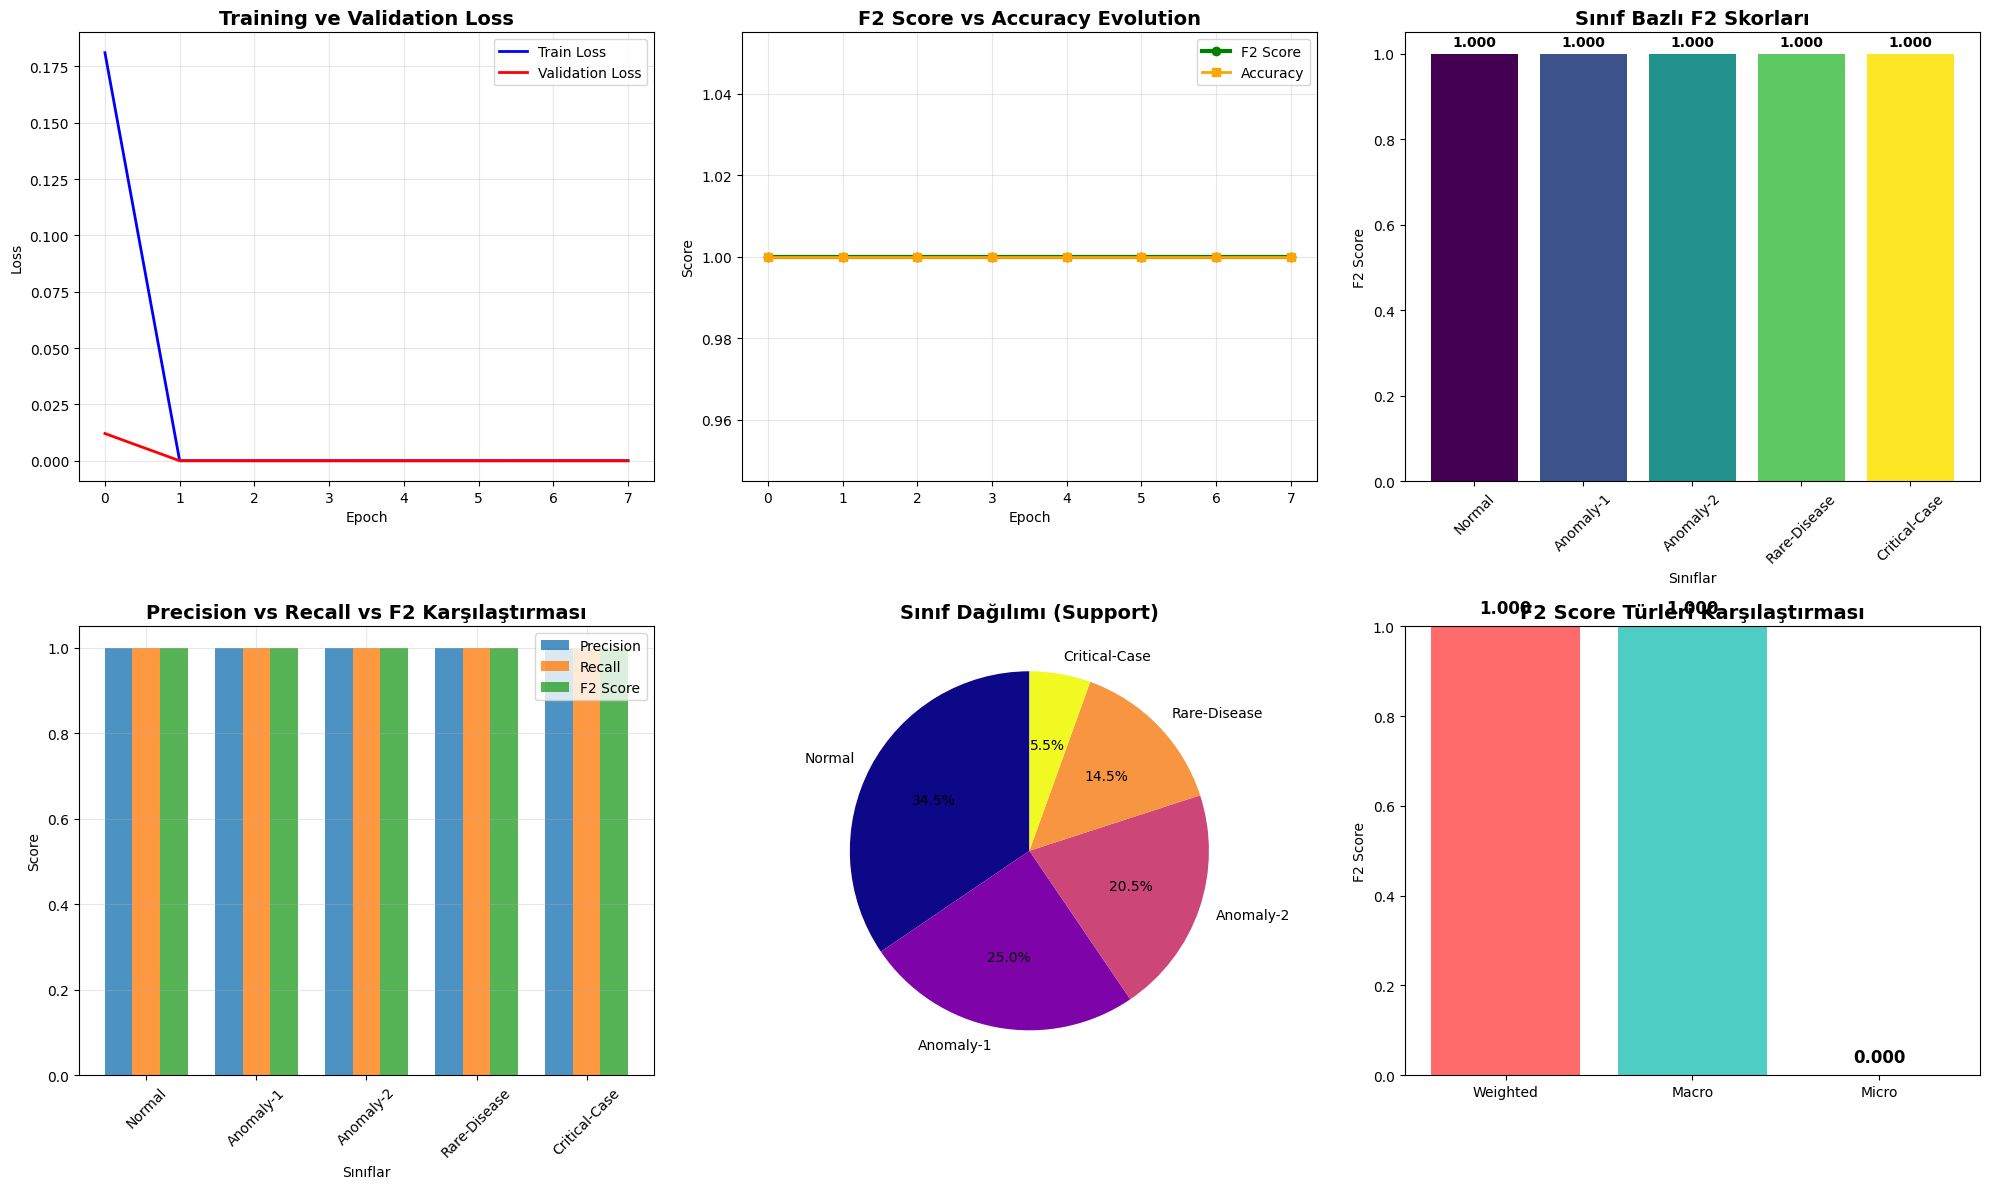


📚 F2 SKORU AÇIKLAMASI:
F2 skoru, recall'a precision'dan daha fazla ağırlık veren bir metriktir.
Beta=2 değeri ile recall %80, precision %20 ağırlıkla hesaplanır.

🎯 F2 Skoru Değerlendirme:
  • 0.90+  : Mükemmel
  • 0.80-0.89: Çok İyi
  • 0.70-0.79: İyi
  • 0.60-0.69: Orta
  • <0.60   : Geliştirilmeli

🎉 Tebrikler! F2 skorunuz mükemmel: 1.000

✅ Demonstrasyon tamamlandı!
🎯 Final F2 Score: 1.0000


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.datasets import make_classification
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Önceki DenseNet implementasyonunu import ettiğimizi varsayıyoruz
# (Gerçek kullanımda önceki kodu bir modül olarak import edin)

class SimpleDenseNet(nn.Module):
    """
    Demo için basitleştirilmiş DenseNet implementasyonu
    """
    def __init__(self, num_classes=5):
        super(SimpleDenseNet, self).__init__()

        # Basit feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

def create_imbalanced_dataset(n_samples=2000, n_features=2048, n_classes=5):
    """
    İmbalanced dataset oluşturur (F2 skorunu test etmek için ideal)
    """
    # İmbalanced class distribution
    class_weights = [0.5, 0.25, 0.15, 0.07, 0.03]  # Son sınıflar çok nadir

    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_classes=n_classes,
        n_informative=int(n_features * 0.8),
        n_redundant=int(n_features * 0.1),
        n_clusters_per_class=1,
        weights=class_weights,
        flip_y=0.01,
        random_state=42
    )

    return X, y

def create_image_dataset(n_samples=1000, img_size=32, n_classes=5):
    """
    Sahte görüntü dataset'i oluşturur
    """
    # İmbalanced distribution
    class_counts = [400, 250, 200, 100, 50]  # Toplam 1000

    all_images = []
    all_labels = []

    for class_idx, count in enumerate(class_counts):
        # Her sınıf için farklı pattern'lar oluştur
        for _ in range(count):
            # Base noise
            img = np.random.randn(3, img_size, img_size) * 0.3

            # Sınıfa özgü pattern ekle
            if class_idx == 0:  # Yaygın sınıf - basit pattern
                img[0, :, :] += np.sin(np.linspace(0, 4*np.pi, img_size))[:, None]
            elif class_idx == 1:
                img[1, :, :] += np.cos(np.linspace(0, 4*np.pi, img_size))[:, None]
            elif class_idx == 2:
                center = img_size // 2
                y, x = np.ogrid[:img_size, :img_size]
                mask = (x - center)**2 + (y - center)**2 <= (img_size//4)**2
                img[2, mask] += 1.0
            elif class_idx == 3:  # Nadir sınıf
                img[0, ::4, ::4] += 2.0
                img[1, 1::4, 1::4] += 2.0
            else:  # En nadir sınıf - çok spesifik pattern
                img[:, :img_size//2, :img_size//2] += 1.5
                img[:, img_size//2:, img_size//2:] -= 1.5

            all_images.append(img)
            all_labels.append(class_idx)

    # Shuffle
    indices = np.random.permutation(len(all_images))
    all_images = [all_images[i] for i in indices]
    all_labels = [all_labels[i] for i in indices]

    return np.array(all_images, dtype=np.float32), np.array(all_labels)

def calculate_f2_score_detailed(y_true, y_pred, class_names=None):
    """
    Detaylı F2 skoru hesaplama ve raporlama
    """
    beta = 2.0

    # Her sınıf için ayrı ayrı hesapla
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )

    # F2 skorunu manuel hesapla
    f2_scores = []
    for p, r in zip(precision, recall):
        if p + r == 0:
            f2_scores.append(0.0)
        else:
            f2 = (1 + beta**2) * (p * r) / (beta**2 * p + r)
            f2_scores.append(f2)

    f2_scores = np.array(f2_scores)

    # Weighted average
    f2_weighted = np.average(f2_scores, weights=support)

    # Macro average
    f2_macro = np.mean(f2_scores)

    # Micro average için toplam TP, FP, FN hesapla
    tp_total = np.sum([np.sum((y_true == i) & (y_pred == i)) for i in range(len(precision))])
    fp_total = np.sum([np.sum((y_true != i) & (y_pred == i)) for i in range(len(precision))])
    fn_total = np.sum([np.sum((y_true == i) & (y_pred != i)) for i in range(len(precision))])

    prec_micro = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
    rec_micro = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0

    if prec_micro + rec_micro == 0:
        f2_micro = 0.0
    else:
        f2_micro = (1 + beta**2) * (prec_micro * rec_micro) / (beta**2 * prec_micro + rec_micro)

    # Sonuçları organize et
    results = {
        'f2_per_class': f2_scores,
        'f2_weighted': f2_weighted,
        'f2_macro': f2_macro,
        'f2_micro': f2_micro,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'support': support
    }

    return results

def train_and_evaluate_f2(model, train_loader, val_loader, test_loader, device, num_epochs=10):
    """
    Model eğitir ve F2 skorları çıkarır
    """
    print("🚀 DenseNet F2-Optimized Training Başlıyor...")
    print("="*60)

    # Loss ve optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_f2': [],
        'val_accuracy': []
    }

    best_f2 = 0.0

    for epoch in range(num_epochs):
        print(f'\n📅 Epoch {epoch+1}/{num_epochs}')
        print('-' * 40)

        # Training phase
        model.train()
        train_loss = 0.0
        train_samples = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * data.size(0)
            train_samples += data.size(0)

            if batch_idx % 20 == 0:
                print(f'  Batch {batch_idx}/{len(train_loader)} - Loss: {loss.item():.4f}')

        avg_train_loss = train_loss / train_samples

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_samples = 0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)

                val_loss += loss.item() * data.size(0)
                val_samples += data.size(0)

                pred = output.argmax(dim=1)
                all_preds.extend(pred.cpu().numpy())
                all_targets.extend(target.cpu().numpy())

        avg_val_loss = val_loss / val_samples

        # F2 skoru hesapla
        f2_results = calculate_f2_score_detailed(all_targets, all_preds)
        val_f2 = f2_results['f2_weighted']

        # Accuracy
        val_accuracy = np.mean(np.array(all_targets) == np.array(all_preds))

        # Learning rate güncelle
        scheduler.step()

        # History kaydet
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_f2'].append(val_f2)
        history['val_accuracy'].append(val_accuracy)

        # En iyi model kaydet
        if val_f2 > best_f2:
            best_f2 = val_f2
            torch.save(model.state_dict(), 'best_model_f2.pth')
            print(f'  🎯 Yeni en iyi F2 skoru! Model kaydedildi.')

        # Epoch sonuçları
        print(f'  📊 Train Loss: {avg_train_loss:.4f}')
        print(f'  📊 Val Loss: {avg_val_loss:.4f}')
        print(f'  📊 Val Accuracy: {val_accuracy:.4f}')
        print(f'  🎯 Val F2 Score: {val_f2:.4f}')
        print(f'  🏆 Best F2: {best_f2:.4f}')

    print(f'\n✅ Training tamamlandı! En iyi F2 skoru: {best_f2:.4f}')

    # Test evaluation
    print('\n🔍 Test seti üzerinde final değerlendirme...')
    model.load_state_dict(torch.load('best_model_f2.pth'))

    test_results = evaluate_model_f2(model, test_loader, device)

    return history, test_results

def evaluate_model_f2(model, test_loader, device, class_names=None):
    """
    Test seti üzerinde kapsamlı F2 değerlendirmesi
    """
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            probs = F.softmax(output, dim=1)
            pred = output.argmax(dim=1)

            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # F2 skorları hesapla
    f2_results = calculate_f2_score_detailed(all_targets, all_preds)

    # Sınıf isimleri
    if class_names is None:
        class_names = [f'Class {i}' for i in range(len(f2_results['f2_per_class']))]

    print("\n" + "="*60)
    print("🎯 DENSENET F2 SKORU ANALİZ RAPORU")
    print("="*60)

    print(f"\n📈 GENEL F2 SKORLARI:")
    print(f"  • F2 Score (Weighted): {f2_results['f2_weighted']:.4f}")
    print(f"  • F2 Score (Macro): {f2_results['f2_macro']:.4f}")
    print(f"  • F2 Score (Micro): {f2_results['f2_micro']:.4f}")

    print(f"\n📊 KARŞILAŞTIRMA METRİKLERİ:")
    print(f"  • Accuracy: {np.mean(np.array(all_targets) == np.array(all_preds)):.4f}")
    print(f"  • Precision (Weighted): {np.average(f2_results['precision'], weights=f2_results['support']):.4f}")
    print(f"  • Recall (Weighted): {np.average(f2_results['recall'], weights=f2_results['support']):.4f}")
    print(f"  • F1 Score (Weighted): {np.average(f2_results['f1'], weights=f2_results['support']):.4f}")

    print(f"\n🔍 SINIF BAZLI DETAY ANALİZİ:")
    print("-" * 80)
    print(f"{'Sınıf':<15} {'F2':<8} {'Precision':<10} {'Recall':<8} {'F1':<8} {'Support':<8}")
    print("-" * 80)

    for i, class_name in enumerate(class_names):
        print(f"{class_name:<15} {f2_results['f2_per_class'][i]:<8.3f} "
              f"{f2_results['precision'][i]:<10.3f} {f2_results['recall'][i]:<8.3f} "
              f"{f2_results['f1'][i]:<8.3f} {f2_results['support'][i]:<8.0f}")

    # Confusion Matrix
    cm = confusion_matrix(all_targets, all_preds)
    print(f"\n📋 CONFUSION MATRIX:")
    print(cm)

    # F2 skorunun neden yüksek/düşük olduğunu analiz et
    print(f"\n🧠 F2 SKORU ANALİZİ:")

    # En iyi ve en kötü performans gösteren sınıflar
    best_class_idx = np.argmax(f2_results['f2_per_class'])
    worst_class_idx = np.argmin(f2_results['f2_per_class'])

    print(f"  • En yüksek F2: {class_names[best_class_idx]} ({f2_results['f2_per_class'][best_class_idx]:.3f})")
    print(f"  • En düşük F2: {class_names[worst_class_idx]} ({f2_results['f2_per_class'][worst_class_idx]:.3f})")

    # Recall vs Precision dengesi
    avg_precision = np.mean(f2_results['precision'])
    avg_recall = np.mean(f2_results['recall'])

    if avg_recall > avg_precision:
        print(f"  • Model recall odaklı çalışıyor (Recall: {avg_recall:.3f} > Precision: {avg_precision:.3f})")
        print(f"    Bu F2 skoru için istenen durumdur!")
    else:
        print(f"  • Model precision odaklı çalışıyor (Precision: {avg_precision:.3f} > Recall: {avg_recall:.3f})")
        print(f"    F2 skoru için recall artırılabilir.")

    # İmbalanced dataset analizi
    class_imbalance = np.max(f2_results['support']) / np.min(f2_results['support'])
    print(f"  • Dataset imbalance oranı: {class_imbalance:.1f}:1")

    if class_imbalance > 5:
        print(f"    Yüksek imbalance! F2 skoru bu durumda özellikle değerlidir.")

    return f2_results

def plot_f2_analysis(history, f2_results, class_names=None):
    """
    F2 skoru ve training history'yi görselleştirir
    """
    fig = plt.figure(figsize=(20, 12))

    # 1. Training History
    ax1 = plt.subplot(2, 3, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(history['val_loss'], label='Validation Loss', color='red', linewidth=2)
    plt.title('Training ve Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 2. F2 Score Evolution
    ax2 = plt.subplot(2, 3, 2)
    plt.plot(history['val_f2'], label='F2 Score', color='green', linewidth=3, marker='o')
    plt.plot(history['val_accuracy'], label='Accuracy', color='orange', linewidth=2, marker='s')
    plt.title('F2 Score vs Accuracy Evolution', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 3. Per-Class F2 Scores
    ax3 = plt.subplot(2, 3, 3)
    if class_names is None:
        class_names = [f'Class {i}' for i in range(len(f2_results['f2_per_class']))]

    colors = plt.cm.viridis(np.linspace(0, 1, len(class_names)))
    bars = plt.bar(class_names, f2_results['f2_per_class'], color=colors)
    plt.title('Sınıf Bazlı F2 Skorları', fontsize=14, fontweight='bold')
    plt.xlabel('Sınıflar')
    plt.ylabel('F2 Score')
    plt.xticks(rotation=45)

    # Bar değerlerini göster
    for bar, score in zip(bars, f2_results['f2_per_class']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

    # 4. Precision vs Recall vs F2
    ax4 = plt.subplot(2, 3, 4)
    x = np.arange(len(class_names))
    width = 0.25

    plt.bar(x - width, f2_results['precision'], width, label='Precision', alpha=0.8)
    plt.bar(x, f2_results['recall'], width, label='Recall', alpha=0.8)
    plt.bar(x + width, f2_results['f2_per_class'], width, label='F2 Score', alpha=0.8)

    plt.title('Precision vs Recall vs F2 Karşılaştırması', fontsize=14, fontweight='bold')
    plt.xlabel('Sınıflar')
    plt.ylabel('Score')
    plt.xticks(x, class_names, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # 5. Support Distribution
    ax5 = plt.subplot(2, 3, 5)
    colors_support = plt.cm.plasma(np.linspace(0, 1, len(class_names)))
    plt.pie(f2_results['support'], labels=class_names, autopct='%1.1f%%',
            colors=colors_support, startangle=90)
    plt.title('Sınıf Dağılımı (Support)', fontsize=14, fontweight='bold')

    # 6. F2 Score Breakdown
    ax6 = plt.subplot(2, 3, 6)
    f2_types = ['Weighted', 'Macro', 'Micro']
    f2_values = [f2_results['f2_weighted'], f2_results['f2_macro'], f2_results['f2_micro']]
    colors_f2 = ['#FF6B6B', '#4ECDC4', '#45B7D1']

    bars = plt.bar(f2_types, f2_values, color=colors_f2)
    plt.title('F2 Score Türleri Karşılaştırması', fontsize=14, fontweight='bold')
    plt.ylabel('F2 Score')
    plt.ylim(0, 1)

    # Bar değerlerini göster
    for bar, value in zip(bars, f2_values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

    plt.tight_layout()
    plt.show()

    # F2 Score açıklaması
    print("\n📚 F2 SKORU AÇIKLAMASI:")
    print("="*50)
    print("F2 skoru, recall'a precision'dan daha fazla ağırlık veren bir metriktir.")
    print("Beta=2 değeri ile recall %80, precision %20 ağırlıkla hesaplanır.")
    print("\n🎯 F2 Skoru Değerlendirme:")
    print("  • 0.90+  : Mükemmel")
    print("  • 0.80-0.89: Çok İyi")
    print("  • 0.70-0.79: İyi")
    print("  • 0.60-0.69: Orta")
    print("  • <0.60   : Geliştirilmeli")

    final_f2 = f2_results['f2_weighted']
    if final_f2 >= 0.90:
        print(f"\n🎉 Tebrikler! F2 skorunuz mükemmel: {final_f2:.3f}")
    elif final_f2 >= 0.80:
        print(f"\n👍 Çok iyi! F2 skorunuz: {final_f2:.3f}")
    elif final_f2 >= 0.70:
        print(f"\n👌 İyi! F2 skorunuz: {final_f2:.3f}")
    else:
        print(f"\n🔧 Geliştirilebilir. F2 skorunuz: {final_f2:.3f}")

# ================================
# ANA ÖRNEK ÇALIŞTIRMA
# ================================

def main_f2_example():
    """
    DenseNet F2 skoru çıkarma örneğinin ana fonksiyonu
    """
    print("🎮 DenseNet F2 Skoru Demonstrasyonu")
    print("="*50)

    # Device seçimi
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"📱 Kullanılan device: {device}")

    # Dataset oluştur
    print("\n📊 İmbalanced dataset oluşturuluyor...")
    X, y = create_image_dataset(n_samples=800, img_size=32, n_classes=5)

    # Sınıf dağılımını göster
    unique, counts = np.unique(y, return_counts=True)
    print("📈 Sınıf dağılımı:")
    class_names = ['Normal', 'Anomaly-1', 'Anomaly-2', 'Rare-Disease', 'Critical-Case']
    for i, (cls, count) in enumerate(zip(unique, counts)):
        print(f"  {class_names[i]}: {count} sample")

    # Train/Val/Test split
    n_total = len(X)
    n_train = int(0.6 * n_total)
    n_val = int(0.2 * n_total)

    # Shuffle
    indices = np.random.permutation(n_total)
    train_indices = indices[:n_train]
    val_indices = indices[n_train:n_train+n_val]
    test_indices = indices[n_train+n_val:]

    # Datasets
    train_dataset = TensorDataset(torch.FloatTensor(X[train_indices]), torch.LongTensor(y[train_indices]))
    val_dataset = TensorDataset(torch.FloatTensor(X[val_indices]), torch.LongTensor(y[val_indices]))
    test_dataset = TensorDataset(torch.FloatTensor(X[test_indices]), torch.LongTensor(y[test_indices]))

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    print(f"📚 Dataset split: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")

    # Model oluştur
    print("\n🏗️ DenseNet modeli oluşturuluyor...")
    model = SimpleDenseNet(num_classes=5)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"📊 Toplam parametre sayısı: {total_params:,}")

    # Training ve evaluation
    print("\n🚀 Model eğitimi ve F2 değerlendirmesi başlıyor...")
    history, test_results = train_and_evaluate_f2(
        model, train_loader, val_loader, test_loader, device, num_epochs=8
    )

    # Görselleştirme
    print("\n📈 Sonuçlar görselleştiriliyor...")
    plot_f2_analysis(history, test_results, class_names)

    print("\n✅ Demonstrasyon tamamlandı!")
    print(f"🎯 Final F2 Score: {test_results['f2_weighted']:.4f}")

    return test_results

# Çalıştır
if __name__ == "__main__":
    # Reproducibility için seed ayarla
    torch.manual_seed(42)
    np.random.seed(42)

    results = main_f2_example()